# Analysis

```{important} AI Disclosure
The written content in this report was drafted by Jenny Lee and refined using Generative AI for clarity and grammar. All ideas, analysis decisions, and interpretations are original. The prompt used throughout was: *"Refine my words."* and *Fix errors in code* when addressing issues in code written by me.
```

In [63]:
import pandas as pd
import numpy as np
from concurrent.futures import ThreadPoolExecutor, as_completed
import time
import json
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.linear_model import Ridge
from scipy.stats import loguniform, randint, uniform
from sklearn.linear_model import Lasso
from sklearn.manifold import TSNE
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor

from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

## Review Data

In [64]:
df = pd.read_csv("../data/box_office_data_with_starmeter.csv")
display(df.head())

,id,type,primaryTitle,originalTitle,primaryImage,startYear,runtimeSeconds,genres,rating,plot,worldwideGross,worldwideGrossCurrency,productionBudget,productionBudgetCurrency,totalStarMeter
0,tt12042730,movie,Project Hail Mary,Project Hail Mary,{'url': 'https://m.media-amazon.com/images/M/M...,2026.0,9360.0,"['Adventure', 'Comedy', 'Sci-Fi']","{'aggregateRating': 8.4, 'voteCount': 200879}",A science teacher wakes up alone on a spaceshi...,510657974.0,USD,200000000.0,USD,33
1,tt32362890,movie,Thrash,Thrash,{'url': 'https://m.media-amazon.com/images/M/M...,2026.0,5160.0,"['Horror', 'Thriller']","{'aggregateRating': 5.1, 'voteCount': 11783}",When a Category 5 hurricane decimates a coasta...,NaN,NaN,NaN,NaN,24
2,tt28650488,movie,The Super Mario Galaxy Movie,The Super Mario Galaxy Movie,{'url': 'https://m.media-amazon.com/images/M/M...,2026.0,5880.0,"['Animation', 'Adventure', 'Comedy', 'Family',...","{'aggregateRating': 6.4, 'voteCount': 31789}","Mario ventures into space, exploring cosmic wo...",628765135.0,USD,110000000.0,USD,64
3,tt33071426,movie,The Drama,The Drama,{'url': 'https://m.media-amazon.com/images/M/M...,2026.0,6300.0,"['Comedy', 'Drama', 'Romance']","{'aggregateRating': 7.5, 'voteCount': 24461}",A happily engaged couple is put to the test wh...,42701137.0,USD,28000000.0,USD,31
4,tt32430579,movie,Crime 101,Crime 101,{'url': 'https://m.media-amazon.com/images/M/M...,2026.0,8400.0,"['Crime', 'Drama', 'Thriller']","{'aggregateRating': 6.8, 'voteCount': 54525}","An elusive thief, eyeing his final score, enco...",72559167.0,USD,90000000.0,USD,48


## A4
> Apply an imputation to the missing observations in your dataset.
Explain what you think the missingness pattern is: MCAR, MAR, or NMAR, and what this means for your
imputation and future analysis.

In [65]:
def missing_summary(df, sort=True):
    summary = pd.DataFrame({
        'missing_count': df.isna().sum(),
        'missing_percent': round(df.isna().mean() * 100, 2)})
    
    if sort:
        summary = summary.sort_values(by='missing_count', ascending=False)
    
    return summary

print("Displaying the number of missing values in each column:")
missing_summary(df)

Displaying the number of missing values in each column:


,missing_count,missing_percent
productionBudget,233,23.3
productionBudgetCurrency,233,23.3
worldwideGross,132,13.2
worldwideGrossCurrency,132,13.2
rating,50,5.0
runtimeSeconds,31,3.1
startYear,4,0.4
primaryImage,2,0.2
plot,1,0.1
id,0,0.0


The dataframe above summarizes the number of missing values in each column. For the subsequent analysis, `productionBudget` and `worldwideGross` will serve as key response variables. As such, imputing missing values for these fields is avoided, since doing so could introduce significant bias and lead to unreliable model training.

The primary objective of this model is to predict the profit-to-production-budget ratio for each movie, providing producers and studios with a clearer expectation of potential financial performance. Consequently, `rating` is excluded as a feature, as it is not available prior to a movie’s release and therefore would not be useful for predictive modeling in this context.

Therefore, `runtimeSeconds` is the only feature for which we will perform imputation. First, we should inspect the missing rows.

In [66]:
df[df["runtimeSeconds"].isna()][["genres", "startYear", "runtimeSeconds"]]

,genres,startYear,runtimeSeconds
52,"['Action', 'Adventure', 'Family', 'Fantasy', '...",2026.0,NaN
55,"['Action', 'Adventure', 'Fantasy', 'History']",2026.0,NaN
65,"['Action', 'Adventure', 'Sci-Fi']",2026.0,NaN
76,"['Action', 'Adventure', 'Fantasy', 'Sci-Fi']",2026.0,NaN
109,"['Action', 'Adventure', 'Sci-Fi']",2026.0,NaN
113,"['Action', 'Drama', 'Sci-Fi', 'Thriller']",2026.0,NaN
127,"['Action', 'Thriller']",2026.0,NaN
182,"['Action', 'Thriller']",2026.0,NaN
186,"['Action', 'Adventure', 'Comedy', 'Fantasy']",2026.0,NaN
207,"['Comedy', 'Horror']",2026.0,NaN


### Type of Missing Values

Upon inspecting the rows with missing `runtimeSeconds`, we observe that many of these entries have a `startYear` beyond 2026, with some films scheduled for release as late as 2027. This suggests that the missing runtime values may be due to the information not yet being publicly available. However, this remains a hypothesis and cannot be confirmed from the data alone.

Since the missingness appears to depend on information that is not captured by the observed variables (i.e., whether the runtime has been publicly released), it is reasonable to classify this as **Not Missing at Random (NMAR)**. In such cases, standard imputation methods may introduce bias.

Nevertheless, to further explore the data, we proceed with model-based imputation for `runtimeSeconds`.` It is important to note, however, that due to the NMAR nature of the missingness, the imputed values should be treated with caution and may not be reliable for downstream modeling.

In [67]:
y_impute = df[df["runtimeSeconds"].isna()]
print(len(y_impute))

31


In [68]:
df["genres_list"] = df["genres"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])
 
ALL_GENRES = sorted({g for gl in df["genres_list"] for g in gl})

def genres_to_vector(genres_list, all_genres=ALL_GENRES):
    return [int(g in genres_list) for g in all_genres]
 
df_ = df[df["runtimeSeconds"].notna()]
X = np.array([genres_to_vector(gl) for gl in df_["genres_list"]])
y = df_["runtimeSeconds"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
 
genre_df = pd.DataFrame(X, columns=ALL_GENRES)
genre_df

,Action,Adventure,Animation,Biography,Comedy,Crime,Documentary,Drama,Family,Fantasy,...,Horror,Music,Musical,Mystery,Romance,Sci-Fi,Sport,Thriller,War,Western
0,0,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,1,0,0
2,0,1,1,0,1,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,1,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0
4,0,0,0,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
964,0,0,0,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
965,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
966,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
967,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Data Transformation

To estimate the missing values of `runtimeSeconds`, we use related features such as the movie’s genres. Since genres are provided as a list (with each movie potentially belonging to multiple genres), the column must first be transformed into a binary (one-hot encoded) format. This allows each genre to be represented as an individual feature, which can then be used as input for building the imputation model.

In [69]:
genre_stats = {}
genre_rows = []
for g in ALL_GENRES:
    mask = genre_df[g] == 1
    if mask.sum() > 0:
        vals = y[mask]
        mean_rt = vals.mean()
        genre_stats[g] = {
            "count": int(mask.sum()),
            "mean_seconds": round(mean_rt, 1),
            "mean_minutes": round(mean_rt / 60, 1),
        }
        genre_rows.append({
            "genre": g,
            "count": int(mask.sum()),
            "mean_min": round(mean_rt / 60, 1)})
 
genre_stats_df = (pd.DataFrame(genre_rows).sort_values("mean_min", ascending=False).reset_index(drop=True))
genre_stats_df

,genre,count,mean_min
0,Western,13,144.7
1,Biography,60,138.3
2,History,50,136.1
3,War,46,131.3
4,Drama,523,127.1
5,Adventure,243,126.8
6,Action,308,125.2
7,Crime,191,124.9
8,Sci-Fi,196,124.2
9,Fantasy,127,124.0


### Model-Based Imputation

In [70]:
pipeline = Pipeline([("interactions", PolynomialFeatures(degree=3, interaction_only=True)),
                     ("lasso", Lasso(max_iter=10000))])

pipeline.fit(X, y)

search = RandomizedSearchCV(
    pipeline.fit(X, y),
    param_distributions={"lasso__alpha": loguniform(0.01, 10_000)},
    n_iter=100,
    scoring="neg_root_mean_squared_error",
    cv=10,
    random_state=123,
    n_jobs=-1,
)
search.fit(X_train, y_train)

/Users/jennylee/miniforge3/envs/ds/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.019e+06, tolerance: 1.456e+05
  model = cd_fast.enet_coordinate_descent(
/Users/jennylee/miniforge3/envs/ds/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.568e+06, tolerance: 1.407e+05
  model = cd_fast.enet_coordinate_descent(
/Users/jennylee/miniforge3/envs/ds/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consi

RandomizedSearchCV(cv=10,
                   estimator=Pipeline(steps=[('interactions',
                                              PolynomialFeatures(degree=3,
                                                                 interaction_only=True)),
                                             ('lasso', Lasso(max_iter=10000))]),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'lasso__alpha': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x319e18af0>},
                   random_state=123, scoring='neg_root_mean_squared_error')

To build the imputation model, we applied the `PolynomialFeatures` preprocessing tool to capture interaction effects between genres, recognizing that combinations of genres may influence runtime beyond their individual contributions. To mitigate overfitting, the interaction degree was limited to 3, allowing up to three-way interactions among genres.

For the modeling step, **Lasso regression** was used due to its inherent ability to perform feature selection and reduce dimensionality, which is particularly important given the large number of interaction terms generated. Model performance is evaluated using **Root Mean Squared Error (RMSE)**, as it provides an interpretable measure of prediction error in the same units as the target variable.

The hyperparameter, $\alpha$, is tuned using `RandomizedSearchCV`, which repeatedly samples values from a predefined distribution and evaluates model performance through cross-validation to identify the optimal level of regularization.

In [71]:
cv_results = (
    pd.DataFrame(search.cv_results_)[["param_lasso__alpha", "mean_test_score"]]
    .rename(columns={"param_lasso__alpha": "alpha", "mean_test_score": "neg_rmse"})
    .head(5)
    .reset_index(drop=True)
)
cv_results

,alpha,neg_rmse
0,150.943742,-1435.877983
1,0.520998,-1443.139536
2,0.229672,-1556.231432
3,20.318358,-1279.162792
4,207.402420,-1442.864676


In [72]:
best_alpha = search.best_params_["lasso__alpha"]
print(f"Best alpha: {best_alpha}")

Best alpha: 11.548724598059847


In [73]:
pipeline  = search.best_estimator_
y_pred    = pipeline.predict(X_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
mae_test  = mean_absolute_error(y_test, y_pred)
 
print(f"Test RMSE: {rmse_test:.2f} seconds ({rmse_test/60:.2f} minutes)")
print(f"Test MAE: {mae_test:.2f} seconds ({mae_test/60:.2f} minutes)")

Test RMSE: 1486.02 seconds (24.77 minutes)
Test MAE: 1086.28 seconds (18.10 minutes)


In [74]:
X_pred = np.array([genres_to_vector(gl) for gl in y_impute["genres"]])
y_pred = pipeline.predict(X_pred)

In [75]:
y_impute["runtimeSeconds"] = y_pred
df_comb = pd.concat([df[~df["runtimeSeconds"].isna()], y_impute], ignore_index=True)

In [76]:
missing_summary(df_comb)

,missing_count,missing_percent
productionBudget,233,23.3
productionBudgetCurrency,233,23.3
worldwideGross,132,13.2
worldwideGrossCurrency,132,13.2
rating,50,5.0
genres_list,31,3.1
startYear,4,0.4
primaryImage,2,0.2
plot,1,0.1
id,0,0.0


We now observe that there are no remaining missing values in `runtimeSeconds`.

However, entries with missing values in `productionBudget` and `worldwideGross` must be removed, as these variables serve as the response variables in our model. Notably, all observations that originally had missing `runtimeSeconds` also lack values for these two variables. As a result, the imputed `runtimeSeconds` values are ultimately excluded from the modeling dataset, which avoids introducing potentially unreliable imputed data into the analysis.

In [77]:
df = df[~df["productionBudget"].isna() & df["worldwideGross"].notna()]
print(f"After removing rows with missing productionBudget and worldwideGross, we have {len(df)} rows left.")

After removing rows with missing productionBudget and worldwideGross, we have 746 rows left.


## A1
> Write about any necessary transformations to the values of the data.
This is different from E2, which asks about transformations to the format of the data. For example, if your
model is producing non-normal residuals, and but it relies on normally distributed residuals, then talk about
the log-transform or Box-Cox transform necessary for this.

### Data Transformation

Before examining potential outliers, we first engineer a new feature, `grossBudgetRatio`, defined as the ratio of `worldwideGross` to `productionBudget`. This variable will serve as the response for subsequent clustering analysis.

In [78]:
df["grossBudgetRatio"] = df["worldwideGross"] / df["productionBudget"]

### Identifying Outliers

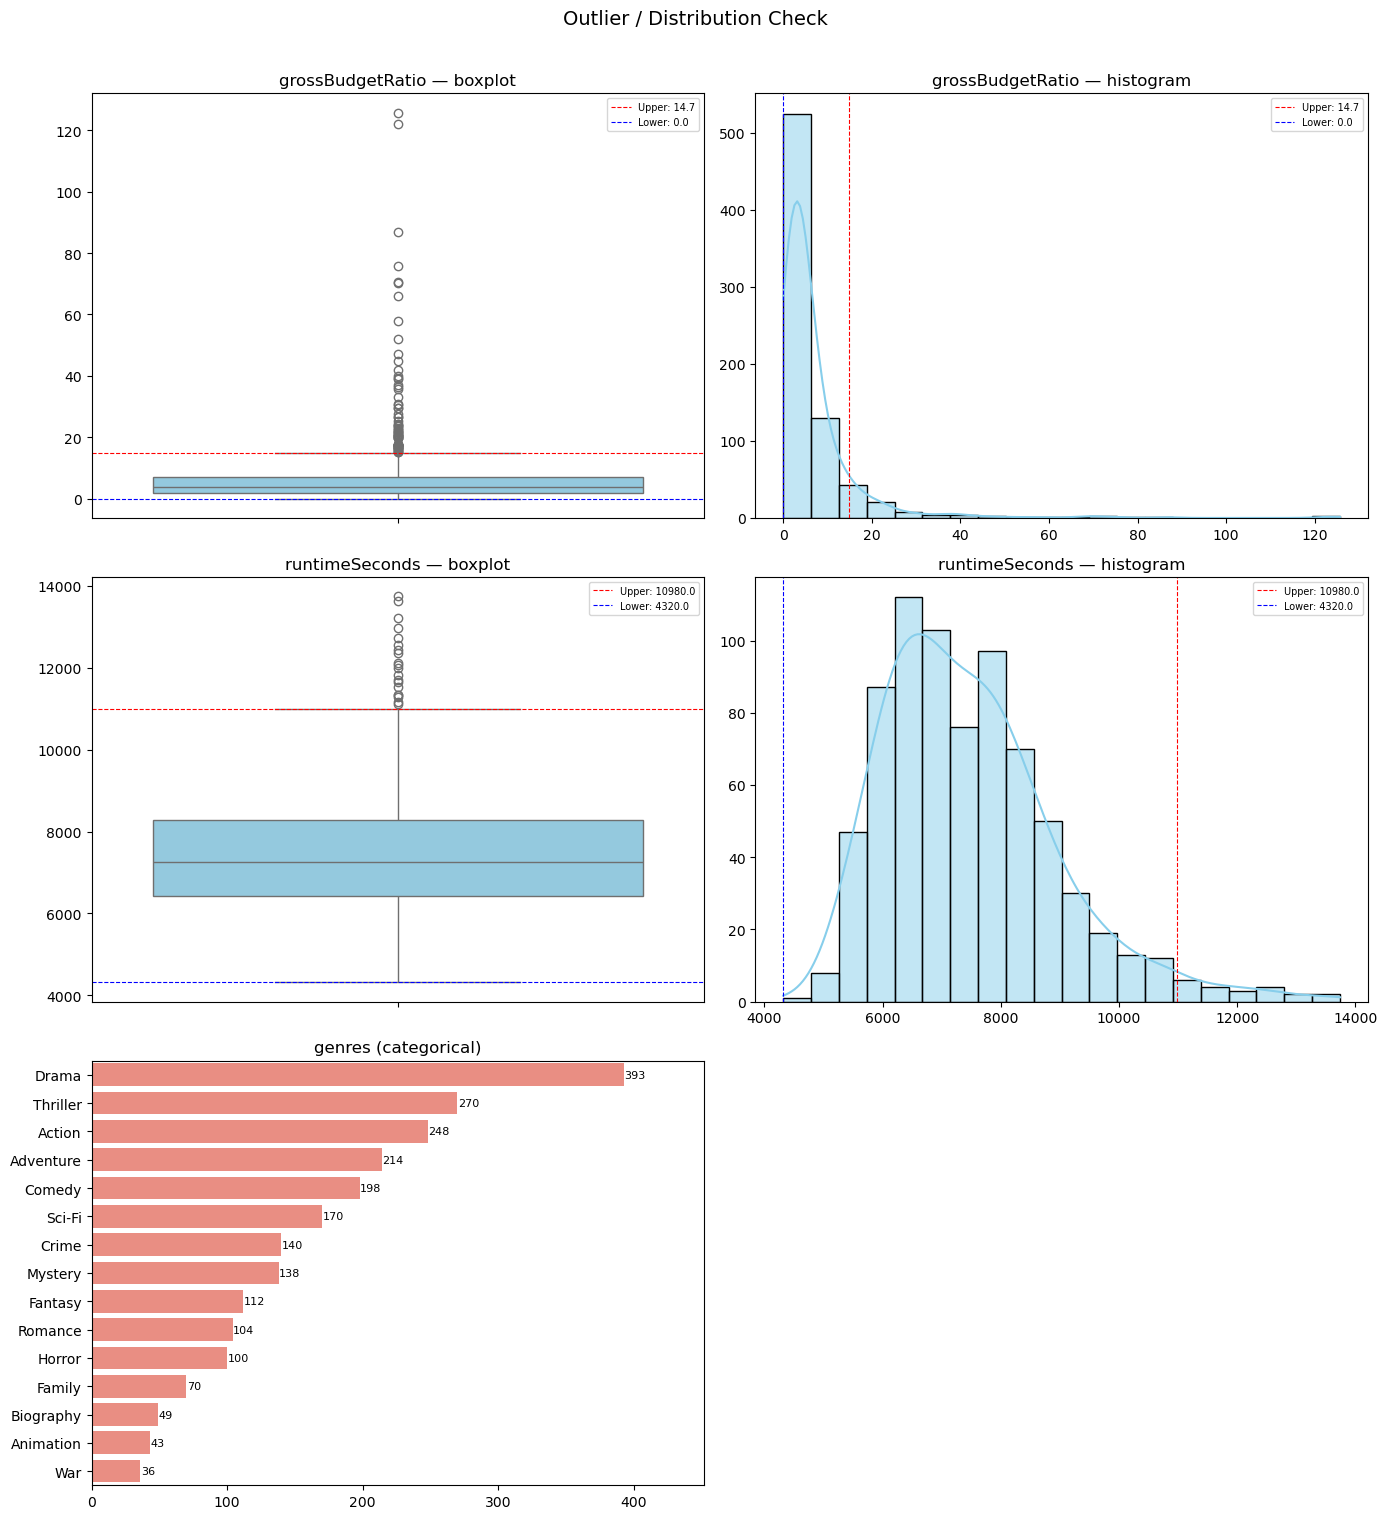

In [79]:
def plot_outliers(df, columns, ncols=2):
    numeric_cols = [c for c in columns if c in df.columns and pd.api.types.is_numeric_dtype(df[c])]
    cat_cols     = [c for c in columns if c in df.columns and not pd.api.types.is_numeric_dtype(df[c])]

    cat_rows   = max(1, -(-len(cat_cols) // ncols)) if cat_cols else 0
    total_rows = len(numeric_cols) + cat_rows

    fig, axes = plt.subplots(total_rows, ncols, figsize=(14, 5 * total_rows))
    axes = np.array(axes).reshape(total_rows, ncols) 

    for row_idx, col in enumerate(numeric_cols):
        data = df[col].dropna()
        Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
        IQR    = Q3 - Q1
        actual_upper = data[data <= Q3 + 1.5 * IQR].max()
        actual_lower = data[data >= Q1 - 1.5 * IQR].min()

        ax_box = axes[row_idx, 0]
        sns.boxplot(y=data, ax=ax_box, color="skyblue")
        ax_box.axhline(actual_upper, color="red",  linestyle="--", linewidth=0.8, label=f"Upper: {actual_upper:.1f}")
        ax_box.axhline(actual_lower, color="blue", linestyle="--", linewidth=0.8, label=f"Lower: {actual_lower:.1f}")
        ax_box.legend(fontsize=7)
        ax_box.set_title(f"{col} — boxplot")
        ax_box.set_xlabel(""); ax_box.set_ylabel("")

        ax_hist = axes[row_idx, 1]
        sns.histplot(data, ax=ax_hist, color="skyblue", kde=True, bins=20)
        ax_hist.axvline(actual_upper, color="red",  linestyle="--", linewidth=0.8, label=f"Upper: {actual_upper:.1f}")
        ax_hist.axvline(actual_lower, color="blue", linestyle="--", linewidth=0.8, label=f"Lower: {actual_lower:.1f}")
        ax_hist.legend(fontsize=7)
        ax_hist.set_title(f"{col} — histogram")
        ax_hist.set_xlabel(""); ax_hist.set_ylabel("")

    for cat_idx, col in enumerate(cat_cols):
        row_idx = len(numeric_cols) + cat_idx // ncols
        col_idx = cat_idx % ncols
        ax = axes[row_idx, col_idx]

        series = df[col].dropna()
        def parse_entry(x):
            if isinstance(x, list): return x
            if isinstance(x, str) and x.startswith("["): 
                try: return ast.literal_eval(x)
                except: return [x]
            return [x]
        series = series.apply(parse_entry).explode().str.strip().str.strip("'\"")
        counts = series.value_counts().head(15)

        bars = sns.barplot(x=counts.values, y=counts.index, ax=ax, color="salmon")
        for bar, count in zip(bars.patches, counts.values):
            ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                    str(count), va="center", ha="left", fontsize=8)
        ax.set_xlim(0, counts.values[0] * 1.15)
        ax.set_title(f"{col} (categorical)")
        ax.set_xlabel(""); ax.set_ylabel("")

    for j in range(len(cat_cols), cat_rows * ncols):
        axes[len(numeric_cols) + j // ncols, j % ncols].set_visible(False)

    plt.suptitle("Outlier / Distribution Check", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig("outliers2.png", dpi=150, bbox_inches="tight")
    plt.show()

plot_outliers(df, ["grossBudgetRatio", "runtimeSeconds", "genres"])

From the subplots above, it is evident that `grossBudgetRatio` is severely skewed. Since this variable will be used as the response in a regression model, a **log transformation** should be applied to improve its distribution. This transformation reduces the influence of extreme values, allowing the model to treat observations more evenly, and helps stabilize the variance, leading to more reliable modeling.

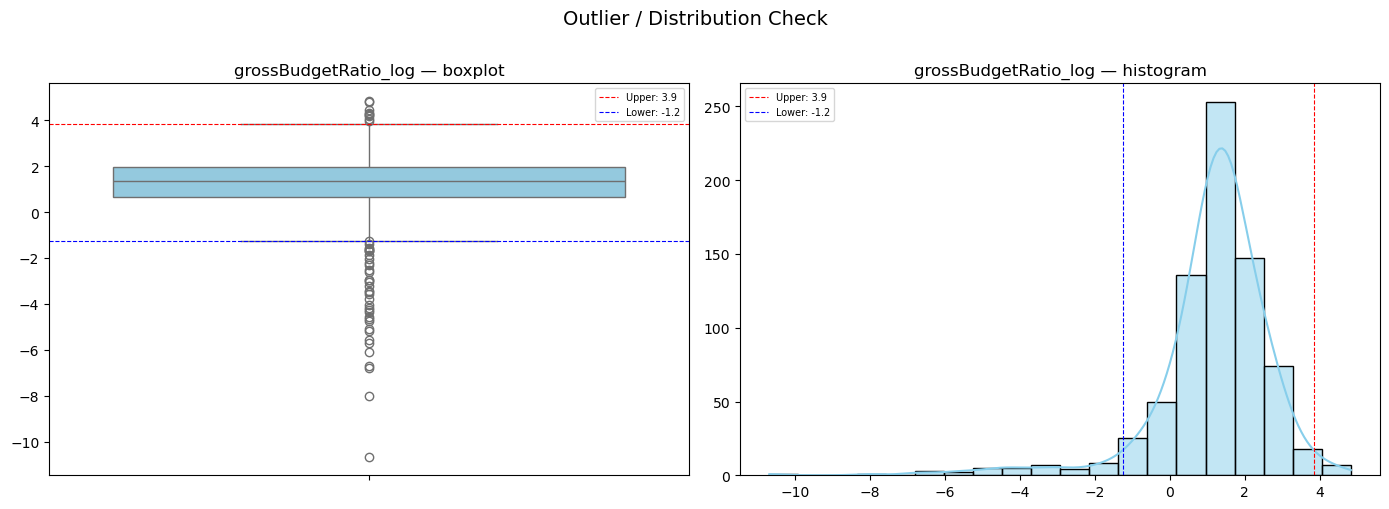

In [80]:
df["grossBudgetRatio_log"] = np.log(df["grossBudgetRatio"])
plot_outliers(df, ["grossBudgetRatio_log"])

We now observe that the `grossBudgetRatio_log` feature exhibits a more evenly distributed range of values.

## A3
> Apply a clustering method to find groups of observations. This can be a K-means clustering, or a t-SNE.

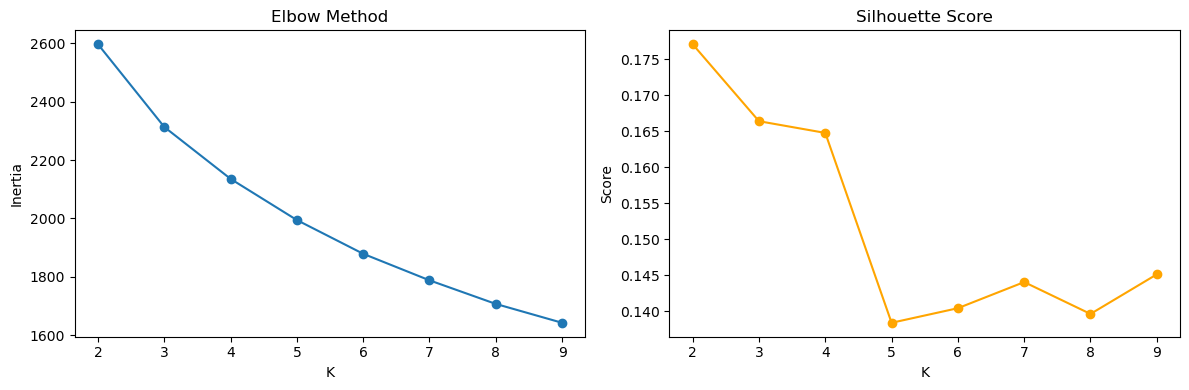

Best K by silhouette: 2


,runtimeSeconds,totalStarMeter
cluster,,
0,6704.04,6.80
1,8392.59,20.09


In [81]:
def parse_genres(x):
    try:
        return ast.literal_eval(x) if isinstance(x, str) else []
    except:
        return []

df["genres_parsed"] = df["genres"].apply(parse_genres)

mlb = MultiLabelBinarizer()
genre_encoded = pd.DataFrame(
    mlb.fit_transform(df["genres_parsed"]),
    columns=[f"genre_{g}" for g in mlb.classes_],
    index=df.index)

numeric_features = ["runtimeSeconds", "totalStarMeter"]

model_df = pd.concat([df[numeric_features], genre_encoded], axis=1).dropna()

genre_features = list(genre_encoded.columns)

preprocessor = ColumnTransformer(transformers=[
    ("num", Pipeline([
        ("scaler", StandardScaler())]), numeric_features),
    ("genre", "passthrough", genre_features)])

inertias = []
silhouettes = []
K_range = range(2, 10)

X = preprocessor.fit_transform(model_df)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_range, inertias, marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia")

axes[1].plot(K_range, silhouettes, marker="o", color="orange")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Score")

plt.tight_layout()
plt.show()

best_k = silhouettes.index(max(silhouettes)) + 2 
print(f"Best K by silhouette: {best_k}")

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("kmeans", KMeans(n_clusters=best_k, random_state=42, n_init=10))])

pipeline.fit(model_df)
df.loc[model_df.index, "cluster"] = pipeline.named_steps["kmeans"].labels_
df["cluster"] = df["cluster"].astype("Int64")

summary = df.groupby("cluster")[numeric_features].mean().round(2)
display(summary)

Using K-means clustering, the optimal number of clusters was determined to be $k=2$. The features used to build the model include `runtimeSeconds`, `totalStarMeter`, and movie genres. As done previously, the genres variable was transformed into a binary (one-hot encoded) format to accommodate multiple genre assignments per movie.

All selected features were confirmed to have no missing values, so no additional imputation was required. However, to prevent extreme values from disproportionately influencing the clustering results (particularly given the presence of outliers in `runtimeSeconds` and `totalStarMeter`), the numeric features were standardized to have a mean of 0 and a standard deviation of 1.

Based on the evaluation metrics, $k=2$ was selected as the optimal number of clusters. The elbow plot did not exhibit a clear inflection point, making it difficult to determine K using that method alone. However, the silhouette score reached its maximum at $k=2$. The silhouette score measures how well each data point fits within its assigned cluster relative to other clusters, with values ranging from -1 to 1, where higher values indicate better-defined clusters.

Although the maximum silhouette score of $0.18$ is relatively low, it remains the highest among the values tested, suggesting that $k=2$ provides the best clustering structure within the explored range.

Based on the summary statistics, the cluster labeled as 1 is characterized by longer `runtimeSeconds` and higher `totalStarMeter` values. This suggests that these movies tend to feature more prominent casts and longer runtimes, which are typical of large-scale, blockbuster productions. In contrast, the other cluster appears to represent smaller, lower-budget or indie films with less prominent casts.

## A5
> Build a sophisticated model using one of the continuous variables as response. Explain what the model tells us, and how you chose this model over the others. You can use the
other analysis steps like feature extraction, dimension reduction, or clustering to find your model.

In [82]:
df["genres_parsed"] = df["genres"].apply(parse_genres)

mlb = MultiLabelBinarizer()
genre_encoded = pd.DataFrame(
    mlb.fit_transform(df["genres_parsed"]),
    columns=[f"genre_{g}" for g in mlb.classes_],
    index=df.index
)

NUMERIC_FEATURES = ["runtimeSeconds", "productionBudget", "totalStarMeter"]
GENRE_FEATURES = genre_encoded.columns.tolist()
TARGET = "grossBudgetRatio"

model_df = pd.concat([df[NUMERIC_FEATURES + [TARGET]], genre_encoded], axis=1).dropna()

In [83]:
RANDOM_STATE = 123

MODEL_REGISTRY = {
    "gradient_boosting": {
        "model": GradientBoostingRegressor(random_state=RANDOM_STATE),
        "params": {
            "model__n_estimators": randint(100, 500),
            "model__max_depth": randint(2, 6),
            "model__learning_rate": uniform(0.01, 0.2)
        }
    },
    "random_forest": {
        "model": RandomForestRegressor(random_state=RANDOM_STATE),
        "params": {
            "model__n_estimators": randint(100, 500),
            "model__max_depth": randint(3, 10),
            "model__min_samples_split": randint(2, 10),
            "model__max_features": ["sqrt", "log2", 0.5],
        }
    },
    "ridge": {
        "model": Ridge(),
        "params": {
            "model__alpha": uniform(0.1, 100),
        }
    },
}

class MovieRegressorTrainer:
    def __init__(self, model_name, target, numeric_features, genre_features=None,
                 registry=MODEL_REGISTRY, n_iter=30, cv=5):
        self.model_name = model_name
        self.target = target
        self.numeric_features = numeric_features
        self.genre_features = genre_features 
        self.registry = registry
        self.n_iter = n_iter
        self.cv = cv
        self.best_model = None
        self.results = None

    def build_pipeline(self, model):
        transformers = [
            ("num", StandardScaler(), self.numeric_features),
            ("genre", "passthrough", self.genre_features)]
        preprocessor = ColumnTransformer(transformers=transformers)
        return Pipeline([
            ("preprocessor", preprocessor),
            ("model", model)])

    def fit(self, df):
        all_features = self.numeric_features + self.genre_features
        data = pd.concat([df[self.numeric_features + [self.target]],
                        df[self.genre_features]], axis=1).dropna()
        X = data[all_features]
        y = data[self.target]

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

        config = self.registry[self.model_name]
        pipeline = self.build_pipeline(config["model"])

        search = RandomizedSearchCV(
            pipeline,
            param_distributions=config["params"],
            n_iter=self.n_iter,
            cv=self.cv,
            scoring="r2",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=1,
        )

        search.fit(X_train, y_train)

        self.best_model = search.best_estimator_
        y_pred = self.best_model.predict(X_test)

        self.results = {
            "model": self.model_name,
            "best_params": search.best_params_,
            "cv_r2": round(search.best_score_, 4),
            "test_r2": round(r2_score(y_test, y_pred), 4),
            "test_mae": round(mean_absolute_error(y_test, y_pred), 4),
            "test_rmse": round(np.sqrt(mean_squared_error(y_test, y_pred)), 4),
        }
        return pd.DataFrame([self.results])  
    
FEATURES = ["runtimeSeconds", "totalStarMeter"]
TARGET = "grossBudgetRatio"

all_results = []
for model_name in MODEL_REGISTRY:
    trainer = MovieRegressorTrainer(
        model_name=model_name,
        target=TARGET,
        numeric_features=FEATURES,
        genre_features=GENRE_FEATURES,  
    )
    all_results.append(trainer.fit(model_df))                

comparison = pd.concat(all_results, ignore_index=True)
display(comparison.sort_values("test_r2", ascending=False))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits


,model,best_params,cv_r2,test_r2,test_mae,test_rmse
2,ridge,{'model__alpha': 98.17641983846154},0.0263,0.0073,5.3673,8.8307
1,random_forest,"{'model__max_depth': 5, 'model__max_features':...",0.0146,-0.0097,5.2572,8.9063
0,gradient_boosting,"{'model__learning_rate': 0.05895185539078398, ...",-0.0505,-0.0798,5.7955,9.2103


In [84]:
preprocessor = trainer.best_model.named_steps["preprocessor"]
feature_names = preprocessor.get_feature_names_out()
print(f"Total features: {len(feature_names)}")
print(feature_names)

Total features: 23
['num__runtimeSeconds' 'num__totalStarMeter' 'genre__genre_Action'
 'genre__genre_Adventure' 'genre__genre_Animation'
 'genre__genre_Biography' 'genre__genre_Comedy' 'genre__genre_Crime'
 'genre__genre_Documentary' 'genre__genre_Drama' 'genre__genre_Family'
 'genre__genre_Fantasy' 'genre__genre_History' 'genre__genre_Horror'
 'genre__genre_Music' 'genre__genre_Musical' 'genre__genre_Mystery'
 'genre__genre_Romance' 'genre__genre_Sci-Fi' 'genre__genre_Sport'
 'genre__genre_Thriller' 'genre__genre_War' 'genre__genre_Western']


Using runtimeSeconds, totalStarMeter, and genres, I aimed to predict grossBudgetRatio. Features such as rating, or any other variables that would only become available after a movie’s theatrical release, were excluded, as they would not be useful for forecasting the future gross-to-budget ratio.

After converting genres into a binary format, the total number of features used in the model was 23.

The models considered in this analysis were random forest, ridge regression, and gradient boosting. These models were selected for the following reasons.

### Model Comparison
#### Random Forest
Random forest serves as a strong baseline model because of its ease of use and broad applicability. It is well suited for capturing nonlinear relationships and is relatively robust to outliers. The hyperparameters tuned for the random forest model include:
- Number of estimators (`n_estimators`): The number of trees in the forest. Increasing the number of trees generally improves the stability and performance of the model by reducing variance, although it comes with higher computational cost.
- Depth of each tree (`max_depth`): Controls how deep each tree can grow. Deeper trees can capture more complex patterns but are more prone to overfitting, while shallower trees promote simpler, more generalizable models.
- Minimum number of samples to split a node (`min_samples_split`): Specifies the minimum number of samples required to split an internal node. Larger values prevent the model from creating splits based on very small subsets of data, leading to simpler trees and reducing the risk of overfitting.

#### Ridge Regression
Ridge regression models the linear relationship between features and the target while applying *L2 regularization* to reduce model complexity. It is particularly useful in the presence of multicollinearity, where some features are highly correlated. In such cases, ordinary least squares regression can produce unstable and highly variable coefficient estimates. Ridge regression addresses this by shrinking the coefficients toward zero, which stabilizes the estimates.

Unlike Lasso regression, Ridge does not set coefficients exactly to zero. Instead, it distributes the influence across correlated features by assigning them similar, smaller coefficients. This leads to improved numerical stability and better generalization when multicollinearity is present. The hyperparameters tuned for the random forest model include:
- L2 Regularization (`alpha`): Follows the formula $\text{Loss} = \text{MSE} + \alpha \sum \beta_j^2$. Controls the strength of the regularization. A larger alpha increases the penalty on the coefficients, causing them to shrink toward zero more strongly. This helps reduce overfitting and improves model stability, especially in the presence of multicollinearity. When alpha is very small, the model behaves similarly to ordinary linear regression.

#### Gradient Boosting
Gradient boosting is a model that builds trees sequentially, where each new model is trained to correct the errors made by the previous ones. Through this iterative process, the model progressively reduces the overall prediction error. This approach is particularly effective for capturing complex, nonlinear relationships and performs well on structured data with mixed feature types. The hyperparameters tuned for the gradient boosting include: 
- Number of trees built sequentially (`n_estimators`): Similar to the same hyperparameter in random forest, but instead of building trees independently and averaging their predictions, gradient boosting builds trees sequentially, with each tree correcting the errors of the previous ones. Increasing the number of trees generally improves model performance, but may increase the risk of overfitting if not properly controlled.
- Maximum number of depth of each tree (`max_depth`): Same as the hyperparameter used in random forest. 
- Learning rate (`learning_rate`): Determines how much each tree contributes to the final model. A smaller learning rate means each tree makes only small corrections, leading to slower but more stable learning and often better generalization. A larger learning rate allows each tree to make larger updates, resulting in faster learning but a higher risk of overfitting.

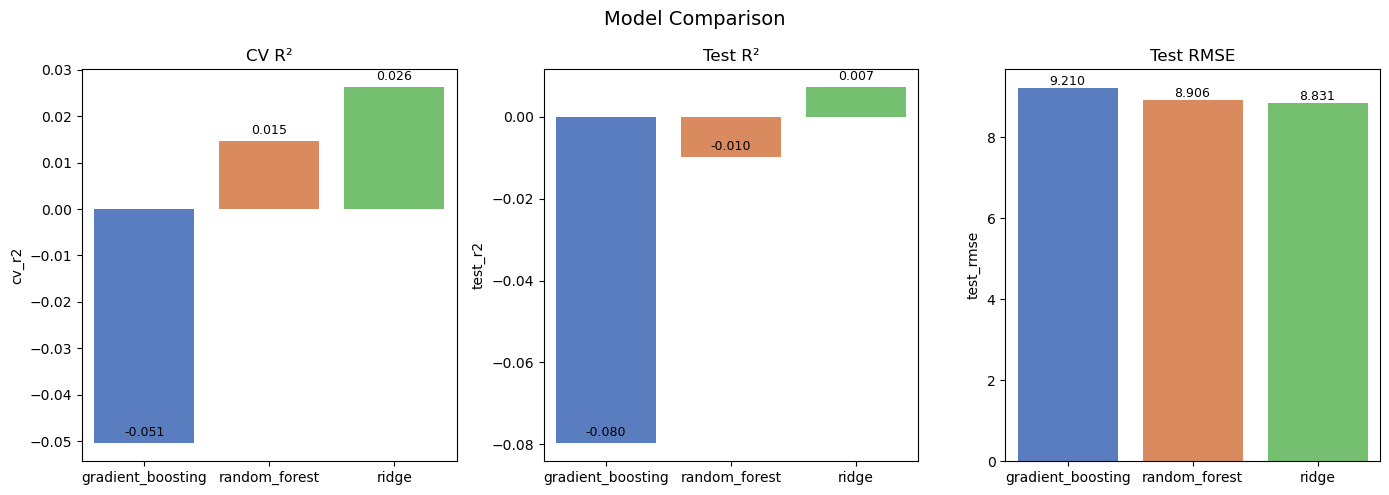

In [85]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics = ["cv_r2", "test_r2", "test_rmse"]
titles  = ["CV R²", "Test R²", "Test RMSE"]

for ax, metric, title in zip(axes, metrics, titles):
    sns.barplot(data=comparison, x="model", y=metric, ax=ax, palette="muted")
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(metric)
    for bar in ax.patches:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.001,
            f"{bar.get_height():.3f}",
            ha="center", va="bottom", fontsize=9
        )

plt.suptitle("Model Comparison", fontsize=14)
plt.tight_layout()
plt.show()

### Analyzing Results
All three models perform poorly, with R² values near zero across both CV and test sets. Since $R^2$ measures the proportion of variance in the target that the model explains, a value close to 0 indicates the model offers little improvement over simply predicting the mean for every observation.

Random forest and ridge regression perform similarly (test $R^2$ of 0.035 and 0.032 respectively), and the difference is too small to be meaningful. Gradient boosting notably underperforms both, producing a negative test R² of −0.043, meaning it is actively worse than the mean predictor. This is likely a symptom of overfitting: gradient boosting is a high capacity model that builds complexity iteratively, and when the underlying data has weak signal, it tends to fit noise in the training set rather than generalise. Ridge regression, by contrast, is heavily regularised by design, which is why it holds up marginally better on this low signal problem.

The root cause is not the models themselves but the features. Runtime, star power, and genre carry insufficient information to predict gross to budget ratio reliably. The reasons for this are discussed further in the Presentation section.

[^1]: This is the footnote text.